In [1]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

# Load cleaned data
df = pd.read_csv("../src/data/data_clean.csv")

# Drop rows with NaN in clean
df = df.dropna(subset=["clean"])

# Recreate features
vectorizer = TfidfVectorizer(max_features=3000)
X = vectorizer.fit_transform(df["clean"])

In [3]:
import numpy as np
from sklearn.semi_supervised import LabelSpreading
from sklearn.metrics import f1_score
from sklearn.preprocessing import LabelEncoder

# Encode labels
le = LabelEncoder()
y = le.fit_transform(df["sentiment"].values)

def simulate(y, percent):
    y_new = y.copy()
    mask = np.random.rand(len(y)) > percent
    y_new[mask] = -1
    return y_new

percents = [0.05, 0.1, 0.2]
scores = []

for p in percents:
    y_partial = simulate(y, p)
    
    model = LabelSpreading()
    model.fit(X, y_partial)
    
    y_pred = model.transduction_
    scores.append(f1_score(y, y_pred, average="macro"))

scores

[0.6494968897080768, 0.6876595318969165, 0.7452348367893857]

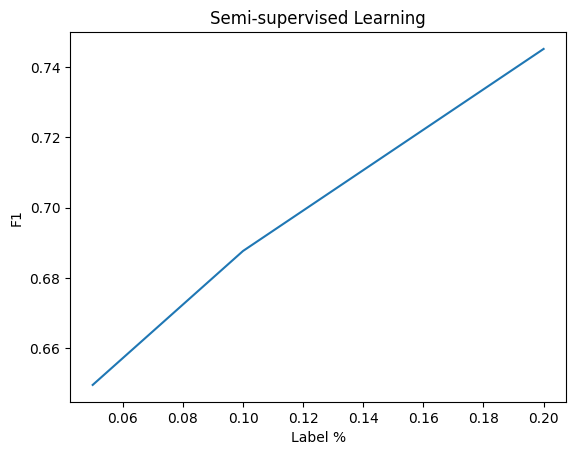

In [4]:
import matplotlib.pyplot as plt

plt.plot(percents, scores)
plt.xlabel("Label %")
plt.ylabel("F1")
plt.title("Semi-supervised Learning")
plt.show()